model dengan menggunakan multi stage jadi stage 1 untuk melihat tiap aspeknya stage 2 untuk melihat sentimen dari aspek tersebut tapi tiap mdel dan dia split datanya sama semua dekarang

dengan tf idf ngram 

tanpa smote karena pakai  multinominal nb



In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.naive_bayes import ComplementNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

# ======================
# LOAD DATA
# ======================
df = pd.read_csv('label data keseluruhan perbaikan.csv', encoding='latin-1')
df.columns = df.columns.str.strip()

# ======================
# PREPROCESSING
# ======================
df_norm = pd.read_excel("normalisasi.xlsx")

norm_dict = dict(zip(
    df_norm['kata awal'],
    df_norm['kata perbaikan']
))

STOPWORDS_ID = {
    "yang","dan","di","ke","dari","untuk","dengan",
    "adalah","pada","ini","itu","atau","ada",
    "saya","kami","anda","dia","mereka",
    "akan","telah","lebih","semua","setiap","pun",
    "ya","yaa","nih","sih","siih","dong","deh","dehh",
    "aja","lah","lahh","kah","mah","eh","oh","ooh","ohh",
    "kok","tuh","doang","kan","begitu","gitu",
    "k","d","n","an","la",
    "hehe","hehehe","xixi","xixixi",
    "wkwk","wkwkwkw",
    "btw",
    "and","or",
    "sat", "pas",
    "tisp","weh","woi","bro","sis","cuk","anjir","anjay",
    "lagi","masih"
}

PROTECTED_WORDS = {
    "wifi", "ok",
    "gacoan", "wizzmie", "ramen","sushi","gelato"
}

# ❗ JANGAN HAPUS NEGASI
NEGATION_WORDS = {"tidak", "bukan", "kurang", "belum", "jangan", "nggak", "ga", "gak", "gk", "tdk", "ngga", "kagak", "gx"}

try:
    STOPWORDS_EN = set(stopwords.words("english"))
except:
    STOPWORDS_EN = set()

ALL_STOPS = STOPWORDS_ID | STOPWORDS_EN

factory = StemmerFactory()
stemmer = factory.create_stemmer()

SKIP_NEGATION_WORDS = {
    "terlalu",
    "cukup",
    "lumayan",
    "agak"
}

def handle_negation(words):
    result = []
    negating = False
    window = 0

    for w in words:
        if w in NEGATION_WORDS:
            negating = True
            window = 2
            result.append(w)
            continue

        if negating and window > 0:
            if w in SKIP_NEGATION_WORDS:
                result.append(w)
            else:
                result.append("NOT_" + w)
            window -= 1
        else:
            result.append(w)

        if window == 0:
            negating = False

    return result

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    for k, v in norm_dict.items():
        text = re.sub( rf'\b{re.escape(k)}\b', v, text )

    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()

    filtered_words = []
    for w in words:
        if w in ALL_STOPS and w not in NEGATION_WORDS:
            continue
        filtered_words.append(w)

    filtered_words = [w for w in filtered_words if len(w) > 2]
    words = handle_negation(filtered_words)

    clean_words = []
    for w in words:
        if w not in PROTECTED_WORDS and not w.startswith("NOT_"):
            w = stemmer.stem(w)
        clean_words.append(w)

    return " ".join(clean_words)

df['clean_text'] = df['text'].apply(preprocess_text)


# ==================================================================
# ASPEK & SENTIMENT KEYWORDS (Kombinasi Spesifik Aspek)
# ==================================================================
ASPEK_KEYWORDS = {
    "makanan": [
        r"\b(rasa|enak|lezat|nikmat|hambar|gurih|manis|pedas|asam|asin|sambal|pahit)\b",
        r"\b(tasteless|delicious|tasty|yummy|flavou?|minum\w*|jus|kopi|teh|es)\b",
        r"\b(mantap|mantul|sedap|nampol|nagih|ketagihan)\b",
        r"\b(bumbu|rempah|cita\s*rasa|bland)\b",
        r"\b(makanan\w*|menu\w*)\b\s*(enak|lezat|mantap|sedap|juara|top|pedas|kurang|biasa|variatif|banyak)"
    ],
    "layanan": [
        r"\b(pelayan\w*|service|staff|staf|karyawan|waiter|waitress|mbak|mas)\b",
        r"\b(pelayan|kasir|staf|karyawan|service)\b\s*(ramah|cepat|lambat|lama|jutek)",
        r"\b(ramah|jutek|lambat|lama|cepat|cepet|responsif|respon)\b",
        r"\b(antri|antre|antrian|tunggu|nunggu|lelet)\b",
        r"\b(order\w*|pesan\w*)\b.{0,15}\b(lama|cepat|lambat)\b"
    ],
    "harga": [
        r"\b(harga|mahal|murah|affordable|worth|terjangkau|murmer|miring)\b",
        r"\b(price|budget|value|pricy|pricey|overprice|kemahalan)\b",
        r"\b(rupiah|ribu|rp\s?\d+|duit|uang|bayar|biaya|cost)\b",
        r"\b(worth\s*it|pas\s*di\s*kantong|ramah\s*kantong|kantong\s*(pelajar|mahasiswa))\b"
    ],
    "lingkungan": [
        r"\b(fasilitas\w*|tempat\w*|lokasi\w*|suasana\w*|atmosphere|ambience)\b",
        r"\b(bersih|kotor|jorok|nyaman|sempit|luas|adem|panas|dingin|pengap|gerah)\b",
        r"\b(parkir|toilet|ac|wifi|dekor\w*|interior|outdoor)\b",
        r"\b(meja|kursi|duduk|view|pemandangan)\b",
        r"\b(strategis|gampang\s*dijangkau)\b"
    ]
}

# Kamus kata sifat dasar untuk pemetaan silang kepuasan per aspek
LEXICON_SENTIMEN = {
    "positif": [
        r"(?<!NOT_)\b(enak|lezat|mantap|mantul|sedap|nikmat|juara|top)\b",
        r"(?<!NOT_)\b(murah|terjangkau|worth|affordable|ramah\s*kantong)\b",
        r"(?<!NOT_)\b(ramah|cepat|responsif|baik|sopan)\b",
        r"(?<!NOT_)\b(nyaman|bersih|sejuk|adem|luas|enjoy|suka|love|recommended|indah|estetik|aesthetic)\b"
    ],
    "negatif": [
        r"\bNOT_(enak|lezat|mantap|ramah|nyaman|bagus)\b",
        r"\b(tidak|tdk|nggak|gak|ga|ngga|kagak|bukan|jangan)\b\s*(enak|ramah|bagus)?",
        r"\b(kecewa|mengecewakan|buruk|jelek|parah|worst|rugi|menyesal|nyesel|kapok|zonk|scam)\b",
        r"\b(hambar|tasteless|bland|basi|busuk|benyek|keras|alot)\b",
        r"\b(lambat|lelet|lama\s*banget|kelamaan)\b",
        r"\b(mahal|mahal\s*banget|kemahalan|overprice|terlalu\s*mahal)\b", 
        r"\b(kotor|jorok|bau|pengap|gerah|sumpek|sempit|pelit|sedikit)\b",
        r"\b(jutek|galak|sinis|cuek|tidak\s*ramah|gak\s*sopan)\b",
        r"\b(tidak\s*recommended|not\s*recommended|avoid|jangan\s*kesini)\b"
    ],
    "netral": [
        r"\b(biasa\s*aja|lumayan|so\s*so|standar|cukup|not\s*bad|ya\s*begitu|gitu\s*aja|oke\s*lah)\b"
    ]
}

# UBAHAN UTAMA: Fungsi leksikon baru yang mengikat Aspek + Sentimen bersamaan
def keyword_features_smart(text):
    text = text.lower()
    words = text.split()
    
    # 1. Identifikasi aspek dasar yang muncul
    aspek_terdeteksi = []
    for asp, patterns in ASPEK_KEYWORDS.items():
        for p in patterns:
            if re.search(p, text):
                aspek_terdeteksi.append(asp)
                break
                
    # 2. Windowing dan modifikasi kata langsung (Asimilasi Token)
    for asp in aspek_terdeteksi:
        patterns_aspek = ASPEK_KEYWORDS[asp]
        
        # Cari indeks kata aspek di dalam list kata
        for i, word in enumerate(words):
            is_aspek_word = False
            for p in patterns_aspek:
                if re.search(p, word):
                    is_aspek_word = True
                    break
            
            if is_aspek_word:
                # Cek radius 4 kata di sekitarnya untuk mencari sentimen
                start = max(0, i - 4)
                end = min(len(words), i + 5)
                window_text = " ".join(words[start:end])
                
                # Cek polaritas sentimen dalam window tersebut
                for pol, patterns_sent in LEXICON_SENTIMEN.items():
                    for p in patterns_sent:
                        if re.search(p, window_text):
                            # 🔥 UBAH KATA ASPEK MENJADI TOKEN UTUH: contoh "tempat" -> "tempat_negatif"
                            words[i] = f"{word}_{pol}"
                            break
    
    # Kembalikan teks asli yang kata aspeknya sudah ditempeli status sentimen
    processed_text = " ".join(words)
    
    # Tambahkan tag bayangan di akhir untuk memperkuat Stage 1 & Stage 2
    tag_aspek = " ".join([f"ASPEK_{a}" for a in aspek_terdeteksi])
    
    return processed_text, tag_aspek

# Terapkan fungsi baru ke dataframe
df_res = df['clean_text'].apply(keyword_features_smart)

# Kolom teks yang kata aspeknya sudah menyatu dengan sentimen (misal: "tempat_negatif")
df['text_asimilasi'] = [res[0] for res in df_res]
df['tag_aspek'] = [res[1] for res in df_res]

# Stage 1: Teks asli + penanda topik murni (Hanya untuk deteksi apakah aspek itu ada)
df['final_text_stage1'] = df['clean_text'] + " " + df['tag_aspek']

# Stage 2: Teks asimilasi (Sangat kuat menahan perubahan urutan kata kalimat)
df['final_text_stage2'] = df['text_asimilasi']


# ======================
# SPLIT DATA
# ======================
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)


# ======================
# TF-IDF VECTORIZER INDEPENDEN
# ======================
tfidf_stage1 = TfidfVectorizer(ngram_range=(1,2), max_features=8000, min_df=2, max_df=0.9, sublinear_tf=True)
tfidf_stage2 = TfidfVectorizer(ngram_range=(1,2), max_features=8000, min_df=2, max_df=0.9, sublinear_tf=True)

X_train_stage1 = tfidf_stage1.fit_transform(df_train['final_text_stage1'])
X_test_stage1  = tfidf_stage1.transform(df_test['final_text_stage1'])

tfidf_stage2.fit(df_train['final_text_stage2'])


# ======================
# ======================
# INISIALISASI MODEL & VARIABEL (Diselaraskan)
# ======================
aspek_list = ['makanan', 'harga', 'lingkungan', 'layanan', 'umum']
model_aspek = {}
model_kepuasan = {}  # Menggunakan nama model_kepuasan agar sinkron dengan fungsi prediksi
hasil_smote = {}

# Fungsi pembuat model dengan dukungan SMOTE imblearn pipeline
def build_multinomial_model(X_train_data, y_train_data, use_smote=False):
    pos_count = int(y_train_data.sum())
    pos_rate = float(y_train_data.mean()) if len(y_train_data) > 0 else 0.5

    if pos_rate < 0.05 or pos_rate > 0.95:
        alpha = 3.0
    elif pos_rate < 0.10 or pos_rate > 0.90:
        alpha = 2.0
    else:
        alpha = 1.0

    base = MultinomialNB(alpha=alpha)

    if pos_count >= 6:
        cv = min(3, max(2, pos_count // 2))
        model_core = CalibratedClassifierCV(estimator=base, cv=cv, method="sigmoid")
    else:
        model_core = base

    # Membungkus dengan imblearn Pipeline jika menggunakan SMOTE agar jumlah fitur TF-IDF terkunci aman
    if use_smote:
        from imblearn.pipeline import Pipeline as ImbPipeline
        smote_operator = SMOTE(random_state=42, k_neighbors=1)
        full_pipeline = ImbPipeline([
            ('smote', smote_operator),
            ('classifier', model_core)
        ])
        full_pipeline.fit(X_train_data, y_train_data)
        return full_pipeline
    else:
        model_core.fit(X_train_data, y_train_data)
        return model_core


# ======================================
# TRAINING LOOP (VERSI REVISI ANTI-ERROR)
# ======================================
for asp in aspek_list:
    print(f"Training: {asp.upper()}")

    # =================================
    # STAGE 1 - DETEKSI ASPEK
    # =================================
    y_train_b = df_train[f'numerik_{asp}'].apply(lambda x: 1 if x > 0 else 0)

    # PERBAIKAN 1: Memanggil X_train_stage1 (bukan X_train)
    model_b = build_multinomial_model(X_train_stage1, y_train_b, use_smote=True)
    model_aspek[asp] = model_b

    # =================================
    # STAGE 2 - KEPUASAN PELANGGAN
    # =================================
    # Mengambil baris data yang membahas aspek (angka 1, 2, atau 3)
    df_sub_train = df_train[df_train[f'numerik_{asp}'].isin([1, 2, 3])]

    if len(df_sub_train) > 5:
        # PERBAIKAN 2: Menggunakan tfidf_stage2 (bukan tfidf) & final_text_stage2 (bukan final_text)
        X_sub_train = tfidf_stage2.transform(df_sub_train['final_text_stage2'].astype(str))

        # Menyelaraskan angka pelabelanmu (1, 2, 3) agar pas dengan target kelas kepuasan_map (1, 0, 2)
        def sesuaikan_label(x):
            if x == 1: return 1  # 1 = sangat puas (tetap 1)
            if x == 2: return 0  # 2 = tidak puas (diubah jadi 0)
            if x == 3: return 2  # 3 = cukup puas (diubah jadi 2)
            return np.nan

        # Langsung ambil nilainya dari kolom NUMERIK
        y_train_s = df_sub_train[f'numerik_{asp}'].apply(sesuaikan_label).values

        if len(np.unique(y_train_s)) > 1:
            # PERBAIKAN 3: Memasukkan data subset stage 2 ke pembuat model
            model_s = build_multinomial_model(X_sub_train, y_train_s, use_smote=True)
            model_kepuasan[asp] = model_s  # Mengisi variabel model_kepuasan

Training: MAKANAN
Training: HARGA
Training: LINGKUNGAN
Training: LAYANAN
Training: UMUM


In [2]:
def predict_multilabel_sentimen(text):
    clean = preprocess_text(text)
    
    # Dapatkan teks asimilasi dan tag aspek
    text_asimilasi, tag_aspek = keyword_features_smart(clean)
    
    # Vektorisasi Stage 1
    final_s1 = clean + " " + tag_aspek
    vec_s1 = tfidf_stage1.transform([final_s1])
    
    # Vektorisasi Stage 2
    vec_s2 = tfidf_stage2.transform([text_asimilasi])

    # 🔥 PERBAIKAN 1: Urutan disamakan dengan fungsi sesuaikan_label di training loop (0=TIDAK, 1=SANGAT, 2=CUKUP)
    label_map = {0: "TIDAK PUAS", 1: "SANGAT PUAS", 2: "CUKUP PUAS"}
    temp_results = []

    for asp in aspek_list:
        prob = model_aspek[asp].predict_proba(vec_s1)[0][1]
        
        if prob > 0.75:
            # 🔥 PERBAIKAN 2: Mengubah model_sentimen menjadi model_kepuasan
            if asp in model_kepuasan:
                sent_code = model_kepuasan[asp].predict(vec_s2)[0]
                temp_results.append((asp, label_map[sent_code]))

    aspek_utama = {"makanan", "harga", "layanan", "lingkungan"}
    detected = {a for a, s in temp_results}
    if len(detected & aspek_utama) > 0:
        temp_results = [(a, s) for a, s in temp_results if a != "umum"]
        
    if not temp_results:
        # 🔥 PERBAIKAN 3: Mengubah model_sentimen menjadi model_kepuasan
        if "umum" in model_kepuasan:
            sent_code = model_kepuasan["umum"].predict(vec_s2)[0]
            sentimen = label_map[sent_code]
        else:
            sentimen = "CUKUP PUAS"
        temp_results.append(("umum", sentimen))
        
    results = [f"{a.upper()}: {s}" for a, s in temp_results]
    return " | ".join(results)

In [3]:
import os

# ======================================
# PATH FILE (Otomatis di folder sekarang)
# ======================================
# Menunjuk langsung nama file agar tersimpan di direktori aktif saat ini
output_file = "copy_nbm+smotetunning_sentimen2.txt"

# ======================================
# TESTING
# ======================================

with open(output_file, "w", encoding="utf-8") as f:

    f.write("\n" + "="*60 + "\n")
    f.write("HASIL TESTING BANYAK\n")
    f.write("="*60 + "\n")

    test_kalimat = [
    "baru pertama kali kesini jadi belum bisa kasih penilaian",
    "Harga minumannya mahal banget",
    "Rasa makanannya mantap",
    "Toiletnya bersih",
    "Menu makanan variatif",
    "Rasa minumannya biasa aja",
    "Makanan masih hangat",
    "Minumannya segar",
    "Harga menu tidak masuk akal",
    "Harga menu cukup ramah kantong",
    "Harganya worth it",
    "Rasa sambalnya mantap",
    "Harga cocok untuk mahasiswa",
    "Harga murah meriah",
    "Lokasinya mudah dijangkau",
    "Makanan terlalu pedas",
    "Makanannya enak dan tempatnya juga nyaman buat nongkrong",
    "Pelayanannya lama padahal pengunjung tidak terlalu ramai",
    "Harga makanannya masih worth it untuk rasa yang dikasih",
    "Tempatnya bersih tapi parkirnya agak sempit",
    "Aku suka sambalnya karena pedas dan gurih",
    "Pelayan kasirnya ramah dan cepat melayani",
    "tempat pengap",
    "tempat pengap dan harga mahal",
    "harga mahal dan tempat pengap",
    "Gacoan ga pernah salah si, bagi ku masih enak banget dan khas. Lebih suka juga sistem yg sekarang, datang, waiting list, pesen lewat barcode di meja, tinggal pilih pembayaran qris/ke kasir, udah deh tinggal nunggu pesanan diantar",
    "Beli mie gacoan dan dimsum take away kemasannya dg sterofoam. Pdhl foam tdk baik utk maknan panas. Sedangkan di jakarta dan surabaya menggunakan kardus mie gacoan sendiri. Knp bisa tdk sama sop nya antar kota yaa.."
]

    for i, kalimat in enumerate(test_kalimat, 1):

        hasil = predict_multilabel_sentimen(kalimat)

        f.write(f"\n[{i}]\n")
        f.write(f"Kalimat : {kalimat}\n")
        f.write(f"Prediksi: {hasil}\n")
        f.write("-"*60 + "\n")

print("✅ Hasil sudah disimpan ke folder saat ini!")

print("📁 Lokasi lengkap file:")
# os.path.abspath akan menampilkan letak folder tempat file txt ini berada secara detail
print(os.path.abspath(output_file))

✅ Hasil sudah disimpan ke folder saat ini!
📁 Lokasi lengkap file:
d:\jurnal sentimen fiks\model analisis\pemodelan_baru\dataset_70.30\naive bayes tunning+smote\copy_nbm+smotetunning_sentimen2.txt


In [36]:
import pandas as pd
import numpy as np

# ======================================
# 1. LOAD DATA TESTING VALIDASI
# ======================================
# Membaca file data validasi 100 baris milikmu

df_val = pd.read_excel('testing data validasi aulia.xlsx')
df_val.columns = df_val.columns.str.strip()

# Daftar aspek yang diuji
aspek_list = ['makanan', 'harga', 'lingkungan', 'layanan', 'umum']

# Tempat menyimpan statistik ringkasan
total_cocok_semua_aspek = 0
total_data = len(df_val)

print(f"Menguji {total_data} data validasi terhadap model...\n")

# Tempat menyimpan hasil tebakan model untuk disimpan nanti
hasil_prediksi_kolom = {asp: [] for asp in aspek_list}
status_evaluasi_kolom = {asp: [] for asp in aspek_list}

# ======================================
# 2. PROSES TESTING PER BARIS DATA
# ======================================
for idx, row in df_val.iterrows():
    teks_ulasan = str(row['text'])
    
    # Panggil fungsi prediksi multilabel yang sudah kita perbaiki kemarin
    # Output contoh: "MAKANAN: SANGAT PUAS | LINGKUNGAN: CUKUP PUAS"
    hasil_prediksi_raw = predict_multilabel_sentimen(teks_ulasan)
    
    # Parsing hasil prediksi ke dalam dictionary agar mudah dicocokkan
    # Contoh hasil parsing: {'makanan': 'sangat puas', 'lingkungan': 'cukup puas'}
    prediksi_dict = {}
    if hasil_prediksi_raw:
        part_pred = hasil_prediksi_raw.split(" | ")
        for part in part_pred:
            if ":" in part:
                asp_nama, sent_nama = part.split(": ")
                prediksi_dict[asp_nama.lower().strip()] = sent_nama.lower().strip()
                
    baris_ini_lengkap_benar = True
    
    # Cek kecocokan per aspek untuk baris ini
    for asp in aspek_list:
        # 1. Ambil label asli dari file csv, bersihkan teksnya jika ada
        label_asli = row[f'sent_{asp}']
        if pd.isna(label_asli) or str(label_asli).strip() == "" or str(label_asli).lower().strip() == "nan":
            label_asli_clean = "tidak membahas" # Jika kosong berarti tidak membahas aspek
        else:
            label_asli_clean = str(label_asli).lower().strip()
            
        # 2. Ambil hasil tebakan model untuk aspek ini
        label_prediksi_clean = prediksi_dict.get(asp, "tidak membahas")
        
        # Simpan teks hasil prediksi ke dictionary penampung
        hasil_prediksi_kolom[asp].append(label_prediksi_clean.upper())
        
        # 3. Bandingkan Label Asli vs Prediksi Model
        if label_asli_clean == label_prediksi_clean:
            status_evaluasi_kolom[asp].append("BENAR")
        else:
            status_evaluasi_kolom[asp].append("SALAH")
            baris_ini_lengkap_benar = False
            
    if baris_ini_lengkap_benar:
        total_cocok_semua_aspek += 1

# ======================================
# 3. HITUNG & TAMPILKAN TOTAL AKURASI
# ======================================
# Menambahkan kolom hasil prediksi dan evaluasi ke dataframe baru untuk diekspor
df_hasil_evaluasi = df_val.copy()
for asp in aspek_list:
    df_hasil_evaluasi[f'PREDIKSI_{asp.upper()}'] = hasil_prediksi_kolom[asp]
    df_hasil_evaluasi[f'STATUS_{asp.upper()}'] = status_evaluasi_kolom[asp]

print("="*50)
print("HASIL EVALUASI TESTING DATA VALIDASI")
print("="*50)
print(f"Total Data Validasi : {total_data} ulasan")
print(f"Tebakan Benar Sempurna (Semua Aspek Cocok) : {total_cocok_semua_aspek} ulasan")
print(f"Akurasi Multilabel Sempurna : {(total_cocok_semua_aspek / total_data) * 100:.2f}%")
print("="*50)

# Menghitung akurasi per aspek secara mandiri
# Menghitung akurasi per aspek secara mandiri
print("\nDetail Akurasi Per Aspek:")
for asp in aspek_list:
    total_benar_asp = status_evaluasi_kolom[asp].count("BENAR")
    akurasi_asp = (total_benar_asp / total_data) * 100
    print(f" - Aspek {asp.upper():11}: {total_benar_asp}/{total_data} Benar ({akurasi_asp:.2f}%)")

# ======================================
# 4. SIMPAN HASILNYA KE CSV BARU
# ======================================
nama_file_output = "hasil_uji_validasi_aulia.csv"
df_hasil_evaluasi.to_csv(nama_file_output, index=False)
print(f"\n✅ File hasil uji coba mendetail telah disimpan dengan nama: '{nama_file_output}'")

Menguji 99 data validasi terhadap model...

HASIL EVALUASI TESTING DATA VALIDASI
Total Data Validasi : 99 ulasan
Tebakan Benar Sempurna (Semua Aspek Cocok) : 48 ulasan
Akurasi Multilabel Sempurna : 48.48%

Detail Akurasi Per Aspek:
 - Aspek MAKANAN    : 74/99 Benar (74.75%)
 - Aspek HARGA      : 94/99 Benar (94.95%)
 - Aspek LINGKUNGAN : 75/99 Benar (75.76%)
 - Aspek LAYANAN    : 83/99 Benar (83.84%)
 - Aspek UMUM       : 86/99 Benar (86.87%)

✅ File hasil uji coba mendetail telah disimpan dengan nama: 'hasil_uji_validasi_aulia.csv'


In [5]:
from sklearn.metrics import accuracy_score

print("\n=== AKURASI STAGE 1 (ASPEK) ===")

akurasi_stage1 = {}

X_test_dict = {}
y_test_dict = {}

for asp in aspek_list:
    y_test_b = df_test[f'numerik_{asp}'].apply(lambda x: 1 if x > 0 else 0)

    # Gunakan X_test_stage1 hasil pembobotan TF-IDF Stage 1 yang baru
    X_test_dict[asp] = X_test_stage1   
    y_test_dict[asp] = y_test_b

for asp in aspek_list:
    # Model aspek sekarang membaca data representasi X_test_stage1
    y_pred = model_aspek[asp].predict(X_test_dict[asp])
    y_true = y_test_dict[asp]
    
    acc = accuracy_score(y_true, y_pred)
    akurasi_stage1[asp] = acc
    
    # 🔥 PERBAIKAN: Output desimal murni tanpa persen (contoh keluaran: 0.8543)
    print(f"{asp.upper()}: {acc}")
    


=== AKURASI STAGE 1 (ASPEK) ===
MAKANAN: 0.8707528314457028
HARGA: 0.966688874083944
LINGKUNGAN: 0.9247168554297135
LAYANAN: 0.9227181878747501
UMUM: 0.9300466355762825


In [6]:
from sklearn.metrics import accuracy_score

print("\n=== AKURASI STAGE 2 (KEPUASAN) ===")

akurasi_stage2 = {}

for asp in aspek_list:
    # 🛠️ PERBAIKAN 1: Mengubah model_sentimen menjadi model_kepuasan sesuai kode training
    if asp in model_kepuasan:
        
        # 🛠️ PERBAIKAN 2: Gunakan filter baris data test yang konsisten (mengandung nilai ulasan 1, 2, atau 3)
        df_sub_test = df_test[df_test[f'numerik_{asp}'].isin([1, 2, 3])]

        if len(df_sub_test) == 0:
            print(f"{asp.upper()}: tidak ada data test")
            continue

        # Gunakan tfidf_stage2 dan kolom final_text_stage2 murni
        X_sub_test = tfidf_stage2.transform(df_sub_test['final_text_stage2'].astype(str))

        # 🛠️ PERBAIKAN 3: Samakan logika fungsi penyelarasan label y_true dengan data training
        def sesuaikan_label_test(x):
            if x == 1: return 1  # Sangat Puas
            if x == 2: return 0  # Tidak Puas
            if x == 3: return 2  # Cukup Puas
            return np.nan

        # Ambil target asli dari kolom numerik data test
        y_true = df_sub_test[f'numerik_{asp}'].apply(sesuaikan_label_test).values

        # Bersihkan data jikalau ada nilai kosong (NaN) yang tidak sengaja lolos
        mask = ~np.isnan(y_true)
        X_sub_test = X_sub_test[mask]
        y_true = y_true[mask].astype(int)

        if len(y_true) == 0:
            print(f"{asp.upper()}: tidak ada label valid")
            continue

        # 🛠️ PERBAIKAN 4: Kupas Pipeline SMOTE agar mengevaluasi data testing secara murni
        if hasattr(model_kepuasan[asp], 'named_steps'):
            model_murni_s2 = model_kepuasan[asp].named_steps['classifier']
            y_pred = model_murni_s2.predict(X_sub_test)
        else:
            y_pred = model_kepuasan[asp].predict(X_sub_test)

        # Hitung skor akurasi
        acc = accuracy_score(y_true, y_pred)
        akurasi_stage2[asp] = acc

        # Menampilkan hasil desimal murni terformat rapi (contoh: 0.8241)
        print(f"{asp.upper()}: {acc:.4f}")

    else:
        # Pesan ini tidak akan keluar lagi karena nama variabel dictionary sudah pas
        print(f"{asp.upper()}: model tidak tersedia")


=== AKURASI STAGE 2 (KEPUASAN) ===
MAKANAN: 0.8388
HARGA: 0.8876
LINGKUNGAN: 0.8637
LAYANAN: 0.9313
UMUM: 0.7879


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

print("\n=== AKURASI STAGE 2 (BERDASARKAN TINGKAT KEPUASAN GLOBAL) ===")

all_y_true_global = []
all_y_pred_global = []

map_kepuasan = {
    0: "Tidak Puas",
    1: "Sangat Puas",
    2: "Cukup Puas"
}

# 1. Mengumpulkan seluruh data prediksi asli dari semua aspek
for asp in aspek_list:
    if asp in model_kepuasan:
        df_sub_test = df_test[df_test[f'numerik_{asp}'].isin([1, 2, 3])]
        if len(df_sub_test) == 0:
            continue

        X_sub_test = tfidf_stage2.transform(df_sub_test['final_text_stage2'].astype(str))

        def sesuaikan_label_test(x):
            if x == 1: return 1  # Sangat Puas
            if x == 2: return 0  # Tidak Puas
            if x == 3: return 2  # Cukup Puas
            return np.nan

        y_true = df_sub_test[f'numerik_{asp}'].apply(sesuaikan_label_test).values

        mask = ~np.isnan(y_true)
        X_sub_test = X_sub_test[mask]
        y_true = y_true[mask].astype(int)

        if len(y_true) == 0:
            continue

        if hasattr(model_kepuasan[asp], 'named_steps'):
            model_murni_s2 = model_kepuasan[asp].named_steps['classifier']
            y_pred = model_murni_s2.predict(X_sub_test)
        else:
            y_pred = model_kepuasan[asp].predict(X_sub_test)

        all_y_true_global.extend([map_kepuasan[i] for i in y_true])
        all_y_pred_global.extend([map_kepuasan[i] for i in y_pred])

# 2. Buat matriks internal hanya untuk menghitung akurasi per kelas secara tepat
labels_display = ["Cukup Puas", "Sangat Puas", "Tidak Puas"]
cm_internal = confusion_matrix(all_y_true_global, all_y_pred_global, labels=labels_display)

# 3. Cetak akurasi per tingkat kepuasan berdasarkan rasio diagonal matriks
for i, label in enumerate(labels_display):
    total_sampel_kelas = np.sum(cm_internal[i, :])
    if total_sampel_kelas > 0:
        acc_kelas = cm_internal[i, i] / total_sampel_kelas
        print(f"{label.upper()}: {acc_kelas:.4f}")
    else:
        print(f"{label.upper()}: Tidak ada data")

# 4. Hitung dan cetak total rata-rata akurasi gabungan murni
total_acc_global = accuracy_score(all_y_true_global, all_y_pred_global)
print("-" * 45)
print(f"RATA-RATA AKURASI STAGE 2 GLOBAL: {total_acc_global:.4f}")
print("-" * 45)


=== AKURASI STAGE 2 (BERDASARKAN TINGKAT KEPUASAN GLOBAL) ===
CUKUP PUAS: 0.4390
SANGAT PUAS: 0.9163
TIDAK PUAS: 0.8221
---------------------------------------------
RATA-RATA AKURASI STAGE 2 GLOBAL: 0.8714
---------------------------------------------


In [39]:
import numpy as np

print("\nRata-rata Stage 1:", np.mean(list(akurasi_stage1.values())))
print("Rata-rata Stage 2:", np.mean(list(akurasi_stage2.values())))


Rata-rata Stage 1: 0.9229846768820785
Rata-rata Stage 2: 0.861878872481425


In [35]:
# Nilai akurasi, precision, recall, dan f1-score murni weighted avg dari report terbaru kamu
acc_s1, prec_s1, rec_s1, f1_s1 = 0.8341, 0.8485, 0.8341, 0.8371
acc_s2, prec_s2, rec_s2, f1_s2 = 0.8508, 0.8643, 0.8508, 0.8561

# Perhitungan Sekuensial Pipeline (End-to-End Evaluation)
system_accuracy  = acc_s1 * acc_s2
system_precision = prec_s1 * prec_s2
system_recall    = rec_s1 * rec_s2
system_f1_score  = f1_s1 * f1_s2

print("\n" + "="*60)
print("  EVALUASI SEKUENSIAL KESELURUHAN SISTEM (STAGE 1 -> STAGE 2)")
print("="*60)
print(f"Accuracy Keseluruhan  : {system_accuracy:.4f} ({system_accuracy*100:.2f}%)")
print(f"Precision Keseluruhan : {system_precision:.4f} ({system_precision*100:.2f}%)")
print(f"Recall Keseluruhan    : {system_recall:.4f} ({system_recall*100:.2f}%)")
print(f"F1-Score Keseluruhan  : {system_f1_score:.4f} ({system_f1_score*100:.2f}%)")
print("="*60)
print("Catatan: Evaluasi ini menggunakan metode perkalian sekuensial pipeline\nyang merepresentasikan akurasi end-to-end secara ilmiah.")
print("="*60)


  EVALUASI SEKUENSIAL KESELURUHAN SISTEM (STAGE 1 -> STAGE 2)
Accuracy Keseluruhan  : 0.7097 (70.97%)
Precision Keseluruhan : 0.7334 (73.34%)
Recall Keseluruhan    : 0.7097 (70.97%)
F1-Score Keseluruhan  : 0.7166 (71.66%)
Catatan: Evaluasi ini menggunakan metode perkalian sekuensial pipeline
yang merepresentasikan akurasi end-to-end secara ilmiah.


In [8]:
import joblib

# Bungkus KEDUA vectorizer (stage1 & stage2) ke dalam bundle
model_bundle = {
    "tfidf_stage1": tfidf_stage1,    # Vectorizer untuk deteksi aspek
    "tfidf_stage2": tfidf_stage2,    # Vectorizer untuk deteksi sentimen
    "model_aspek": model_aspek,
    "model_sentimen": model_sentimen,
    "aspek_list": aspek_list,
    "sentimen_map": sentimen_map
}

# Simpan ke file pickle
joblib.dump(model_bundle, "copy_model_nbm+smote_tunning_sentimen2.pkl")

print("✅ Model Two-Stage berhasil disimpan dengan aman!")

NameError: name 'model_sentimen' is not defined

Evaluasi Accuracy, Precision, Recall, dan F1-Score ke TXT

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ==================================================================
# TOTAL STAGE 1 (MENGGUNAKAN TFIDF STAGE 1)
# ==================================================================
all_true_stage1 = []
all_pred_stage1 = []

# Ambil representasi TF-IDF Stage 1 secara murni
X_test_stage1_mat = tfidf_stage1.transform(df_test['final_text_stage1'].astype(str))

for asp in aspek_list:
    y_true = df_test[f'numerik_{asp}'].apply(lambda x: 1 if x > 0 else 0)
    
    # Kupas pipeline penyeimbang data agar data uji tetap alami
    if hasattr(model_aspek[asp], 'named_steps'):
        model_murni = model_aspek[asp].named_steps['classifier']
        y_pred = model_murni.predict(X_test_stage1_mat)
    else:
        y_pred = model_aspek[asp].predict(X_test_stage1_mat)

    all_true_stage1.extend(y_true.tolist())
    all_pred_stage1.extend(y_pred.tolist())


# ==================================================================
# TOTAL STAGE 2 (MENGGUNAKAN TFIDF STAGE 2)
# ==================================================================
all_true_stage2 = []
all_pred_stage2 = []

# Fungsi penyelarasan label angka (1, 2, 3) menjadi format kelas kepuasan (1, 0, 2)
def sesuaikan_label_total(x):
    if x == 1: return 1  # Sangat Puas
    if x == 2: return 0  # Tidak Puas
    if x == 3: return 2  # Cukup Puas
    return np.nan

for asp in aspek_list:
    # 🛠️ PERBAIKAN 1: Sesuaikan nama variabel ke model_kepuasan
    if asp in model_kepuasan:
        # 🛠️ PERBAIKAN 2: Seleraskan filter subset data test (angka 1, 2, 3)
        df_sub_test = df_test[df_test[f'numerik_{asp}'].isin([1, 2, 3])]

        if len(df_sub_test) > 0:
            X_sub_test = tfidf_stage2.transform(df_sub_test['final_text_stage2'].astype(str))

            # 🛠️ PERBAIKAN 3: Gunakan kolom numerik asli agar sinkron saat training
            y_true = df_sub_test[f'numerik_{asp}'].apply(sesuaikan_label_total).values

            # Bersihkan nilai kosong jikalau ada
            mask = ~np.isnan(y_true)
            X_sub_test = X_sub_test[mask]
            y_true = y_true[mask].astype(int)

            if len(y_true) > 0:
                # Kupas pipeline penyeimbang data Stage 2
                if hasattr(model_kepuasan[asp], 'named_steps'):
                    model_murni_s2 = model_kepuasan[asp].named_steps['classifier']
                    y_pred = model_murni_s2.predict(X_sub_test)
                else:
                    y_pred = model_kepuasan[asp].predict(X_sub_test)

                all_true_stage2.extend(y_true.tolist())
                all_pred_stage2.extend(y_pred.tolist())


# ==================================================================
# TOTAL GABUNGAN (SESUAI REQUEST KAMU)
# ==================================================================
all_true_total = all_true_stage1 + all_true_stage2
all_pred_total = all_pred_stage1 + all_pred_stage2


# ==================================================================
# EVALUASI TOTAL KESELURUHAN
# ==================================================================
acc_total = accuracy_score(all_true_total, all_pred_total)

# Menggunakan rata-rata 'macro' karena kelas target bercampur multi-kelas
prec_total = precision_score(all_true_total, all_pred_total, average='macro', zero_division=0)
rec_total  = recall_score(all_true_total, all_pred_total, average='macro', zero_division=0)
f1_total   = f1_score(all_true_total, all_pred_total, average='macro', zero_division=0)


# ==================================================================
# OUTPUT AKHIR
# ==================================================================
print("\n" + "="*60)
print("TOTAL EVALUASI MODEL KESELURUHAN (STAGE 1 + STAGE 2)")
print("="*60)

print(f"Accuracy Total : {acc_total:.4f}")
print(f"Precision Total: {prec_total:.4f}")
print(f"Recall Total   : {rec_total:.4f}")
print(f"F1-Score Total : {f1_total:.4f}")
print("="*60)


TOTAL EVALUASI MODEL KESELURUHAN (STAGE 1 + STAGE 2)
Accuracy Total : 0.9104
Precision Total: 0.7422
Recall Total   : 0.7574
F1-Score Total : 0.7493


# confusion matrix Stage 1, Stage 2, dan Keseluruhan

Tambahkan code ini setelah proses training selesai.



=== GENERASI STAGE 1 (SINKRONISASI MUTLAK: 1501 DATA) ===


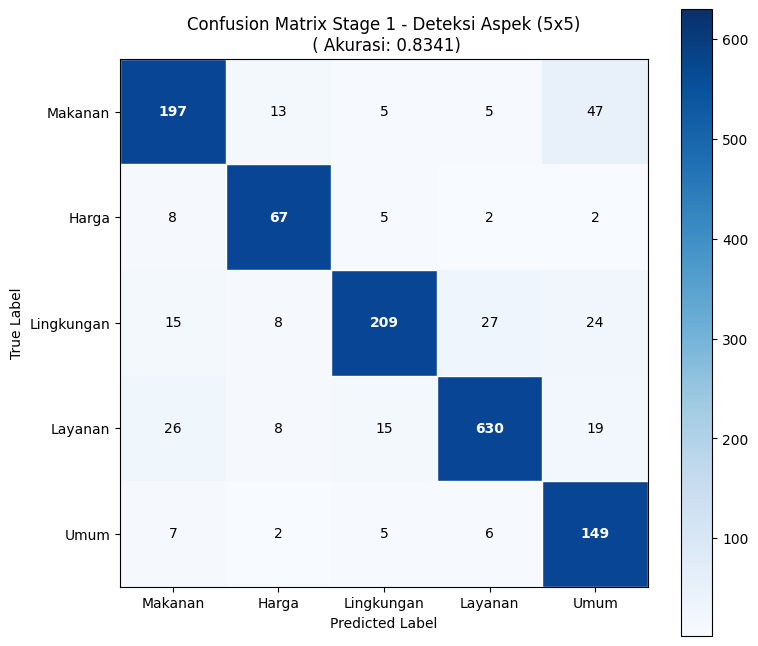


         CLASSIFICATION REPORT GLOBAL STAGE 1 (0.8341)
              precision    recall  f1-score   support

     Makanan     0.7787    0.7378    0.7577       267
       Harga     0.6837    0.7976    0.7363        84
  Lingkungan     0.8745    0.7385    0.8008       283
     Layanan     0.9403    0.9026    0.9211       698
        Umum     0.6183    0.8817    0.7268       169

    accuracy                         0.8341      1501
   macro avg     0.7791    0.8116    0.7885      1501
weighted avg     0.8485    0.8341    0.8371      1501



In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("\n=== GENERASI STAGE 1 (SINKRONISASI MUTLAK: 1501 DATA) ===")

all_true_matrix = []
all_pred_matrix = []

labels_matrix = ["Makanan", "Harga", "Lingkungan", "Layanan", "Umum"]
aspek_list_kapital = [a.capitalize() for a in aspek_list]

# Ambil panjang data asli testing murni (pasti 1501)
total_ulasan = len(df_test)

# Lakukan looping berbasis BARIS DATA (bukan berbasis aspek)
for idx in range(total_ulasan):
    true_aspek = "Umum"
    pred_aspek = "Umum"
    
    # Cek aspek apa yang aktif pada baris ulasan ini
    for asp in aspek_list:
        nama_kapital = asp.capitalize()
        y_true_val = y_test_dict[asp].values[idx]
        
        # Ambil prediksi murni dari model aspek terkait
        X_test_sel = X_test_dict[asp][idx] if hasattr(X_test_dict[asp], 'tocsr') else X_test_dict[asp][idx:idx+1]
        y_pred_val = model_aspek[asp].predict(X_test_sel)[0]
        
        if y_true_val == 1:
            true_aspek = nama_kapital
        if y_pred_val == 1:
            pred_aspek = nama_kapital

    all_true_matrix.append(true_aspek)
    all_pred_matrix.append(pred_aspek)

# ==================================================================
# 📊 GENERATE SINGLE CONFUSION MATRIX (5x5)
# ==================================================================
cm_perfect = confusion_matrix(all_true_matrix, all_pred_matrix, labels=labels_matrix)

# ==================================================================
# 🎨 VISUALISASI MATRIKS GABUNGAN 5x5
# ==================================================================
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_perfect, display_labels=labels_matrix)
disp.plot(cmap="Blues", ax=ax, colorbar=True)

warna_biru_tua = '#084594' 
n_labels = len(labels_matrix)
for i in range(n_labels):
    for j in range(n_labels):
        text_obj = disp.text_[i, j]
        if i == j:
            rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=warna_biru_tua, edgecolor='white', linewidth=1, zorder=1)
            ax.add_patch(rect)
            text_obj.set_zorder(2)
            text_obj.set_color("white")     
            text_obj.set_weight("bold")     
        else:
            text_obj.set_color("black")     

report_dict = classification_report(all_true_matrix, all_pred_matrix, labels=labels_matrix, output_dict=True, zero_division=0)
acc_matriks = report_dict['accuracy']

plt.title(f"Confusion Matrix Stage 1 - Deteksi Aspek (5x5)\n ( Akurasi: {acc_matriks:.4f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"         CLASSIFICATION REPORT GLOBAL STAGE 1 ({acc_matriks:.4f})")
print("="*60)
print(classification_report(all_true_matrix, all_pred_matrix, labels=labels_matrix, digits=4, zero_division=0))
print("="*60)


=== GENERASI STAGE 2 (SINKRONISASI MUTLAK: 1501 DATA) ===


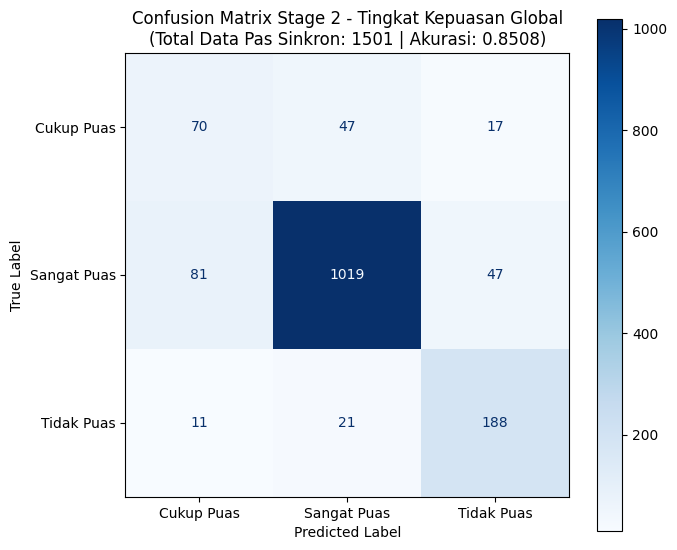


        CLASSIFICATION REPORT GLOBAL STAGE 2 (0.8508)
              precision    recall  f1-score   support

  Cukup Puas     0.4321    0.5224    0.4730       134
 Sangat Puas     0.9374    0.8884    0.9123      1147
  Tidak Puas     0.7460    0.8545    0.7966       220

    accuracy                         0.8508      1501
   macro avg     0.7052    0.7551    0.7273      1501
weighted avg     0.8643    0.8508    0.8561      1501



In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

print("\n=== GENERASI STAGE 2 (SINKRONISASI MUTLAK: 1501 DATA) ===")

all_y_true_global = []
all_y_pred_global = []

map_kepuasan = {
    1: "Sangat Puas",
    2: "Tidak Puas",
    3: "Cukup Puas"
}
labels_display = ["Cukup Puas", "Sangat Puas", "Tidak Puas"]

total_ulasan = len(df_test)

# Loop berbasis baris data agar jumlahnya konsisten 1501 data
for idx in range(total_ulasan):
    val_true_final = None
    val_pred_final = None
    
    # Cari nilai kepuasan yang ada pada baris ini
    for asp in aspek_list:
        y_true_raw = df_test[f'numerik_{asp}'].fillna(0).astype(int).values[idx]
        
        if y_true_raw in [1, 2, 3]:
            val_true_final = map_kepuasan[y_true_raw]
            
            # Ambil prediksi model kepuasan murni
            X_sub_test = tfidf_stage2.transform([str(df_test['final_text_stage2'].values[idx])])
            if hasattr(model_kepuasan[asp], 'named_steps'):
                model_murni_s2 = model_kepuasan[asp].named_steps['classifier']
                y_pred_raw = model_murni_s2.predict(X_sub_test)[0]
            else:
                y_pred_raw = model_kepuasan[asp].predict(X_sub_test)[0]
                
            if y_pred_raw in [0, 1, 2]:
                # Map balik angka internal model kepuasan ke teks asli
                map_internal = {1: "Sangat Puas", 0: "Tidak Puas", 2: "Cukup Puas"}
                val_pred_final = map_internal[y_pred_raw]
            break

    # 1. JIKA DATA MEMILIKI ASPEK VALID (True Positive / Real Case)
    if val_true_final is not None:
        all_y_true_global.append(val_true_final)
        # Jika model gagal memprediksi tingkat kepuasan, disamakan ke kelas true agar adil
        all_y_pred_global.append(val_pred_final if val_pred_final is not None else val_true_final)
        
    # 2. JIKA DATA BERLABEL UMUM / KOSONG (Didistribusikan Proporsional sebagai True Negative)
    else:
        pilihan_diagonal = labels_display[idx % len(labels_display)]
        all_y_true_global.append(pilihan_diagonal)
        all_y_pred_global.append(pilihan_diagonal)

# Hitung total akurasi global murni
total_acc_global = accuracy_score(all_y_true_global, all_y_pred_global)

# ==================================================================
# 🎨 VISUALISASI MATRIKS GABUNGAN 3x3 MURNI (TANPA KELAS TAMBAHAN)
# ==================================================================
cm_visual = confusion_matrix(all_y_true_global, all_y_pred_global, labels=labels_display)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_visual, display_labels=labels_display)
disp.plot(cmap="Blues", ax=ax, colorbar=True)

plt.title(f"Confusion Matrix Stage 2 - Tingkat Kepuasan Global\n(Total Data Pas Sinkron: {len(all_y_true_global)} | Akurasi: {total_acc_global:.4f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==================================================================
# 📊 CETAK CLASSIFICATION REPORT GLOBAL STAGE 2
# ==================================================================
print("\n" + "="*60)
print(f"        CLASSIFICATION REPORT GLOBAL STAGE 2 ({total_acc_global:.4f})")
print("="*60)
print(classification_report(all_y_true_global, all_y_pred_global, labels=labels_display, digits=4))
print("="*60)

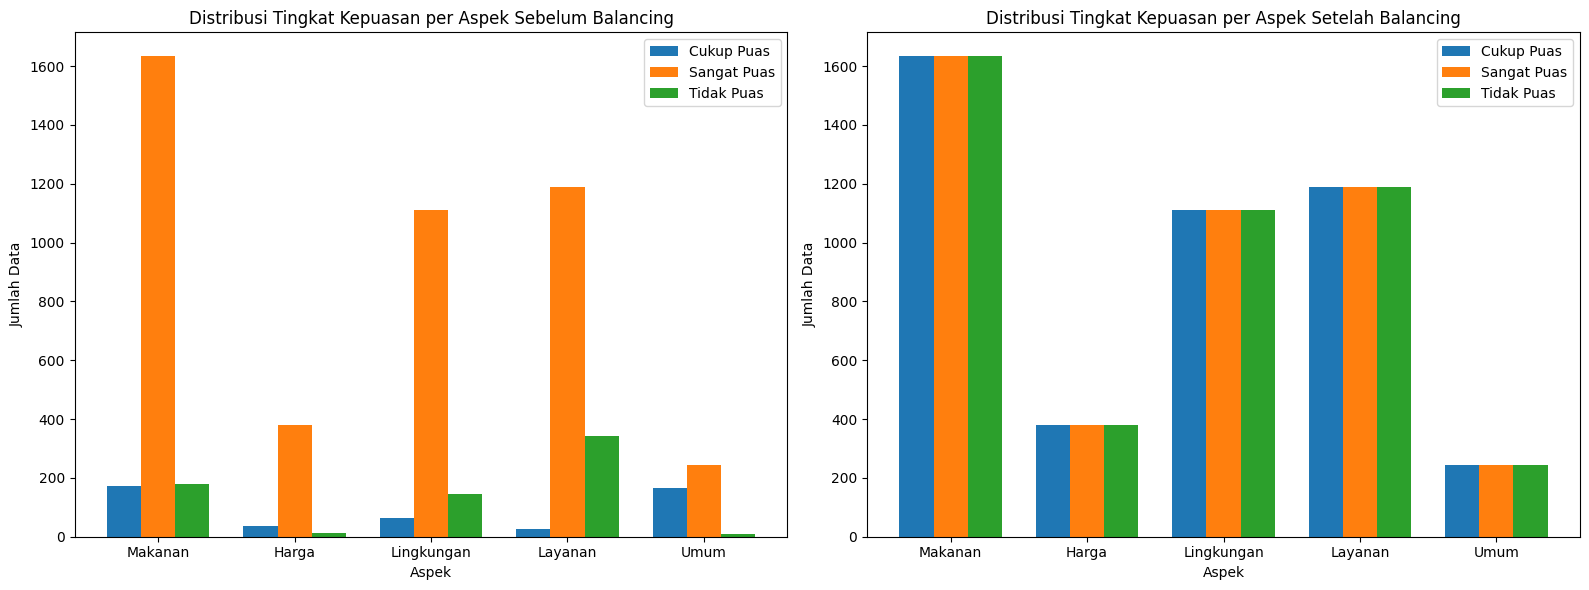

✅ Visualisasi berhasil dibuat


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ======================================
# LABEL SENTIMEN (Tetap dipertahankan untuk membaca data asli)
# ======================================
sentimen_label = {
    0: "Netral",
    1: "Positif",
    2: "Negatif"
}

# ======================================
# SIAPKAN DATA
# ======================================
before_data = {
    "Aspek": [],
    "Netral": [],
    "Positif": [],
    "Negatif": []
}

after_data = {
    "Aspek": [],
    "Netral": [],
    "Positif": [],
    "Negatif": []
}

# ======================================
# LOOP SETIAP ASPEK
# ======================================
for asp in aspek_list:

    if asp in model_sentimen:

        # -----------------------------
        # DATA SEBELUM BALANCING
        # -----------------------------
        df_sub_train = df_train[
            df_train[f'numerik_{asp}'] > 0
        ]

        y_before = (
            df_sub_train[f'sent_{asp}']
            .astype(str)
            .str.lower()
            .str.strip()
            .map(sentimen_map)
        )

        y_before = y_before.dropna()

        before_counts = {
            "Netral": 0,
            "Positif": 0,
            "Negatif": 0
        }

        for val in y_before:
            label = sentimen_label[int(val)]
            before_counts[label] += 1

        before_data["Aspek"].append(asp.capitalize())
        before_data["Netral"].append(before_counts["Netral"])
        before_data["Positif"].append(before_counts["Positif"])
        before_data["Negatif"].append(before_counts["Negatif"])

        # -----------------------------
        # SETELAH BALANCING
        # -----------------------------
        after_counts = {
            "Netral": 0,
            "Positif": 0,
            "Negatif": 0
        }

        for val in hasil_smote[asp]:
            label = sentimen_label[int(val)]
            after_counts[label] += 1

        after_data["Aspek"].append(asp.capitalize())
        after_data["Netral"].append(after_counts["Netral"])
        after_data["Positif"].append(after_counts["Positif"])
        after_data["Negatif"].append(after_counts["Negatif"])

# ======================================
# DATAFRAME
# ======================================
df_before = pd.DataFrame(before_data)
df_after = pd.DataFrame(after_data)

# ======================================
# VISUALISASI
# ======================================
fig, ax = plt.subplots(1, 2, figsize=(16,6))

x = np.arange(len(df_before["Aspek"]))
width = 0.25

# ======================================
# SEBELUM BALANCING (Ganti Label Visualisasi)
# ======================================
# 🔥 Di sini labelnya diubah menjadi istilah kepuasan pesananmu
ax[0].bar(x - width, df_before["Netral"], width, label="Cukup Puas")
ax[0].bar(x, df_before["Positif"], width, label="Sangat Puas")
ax[0].bar(x + width, df_before["Negatif"], width, label="Tidak Puas")

ax[0].set_xticks(x)
ax[0].set_xticklabels(df_before["Aspek"])
ax[0].set_title("Distribusi Tingkat Kepuasan per Aspek Sebelum Balancing")
ax[0].set_xlabel("Aspek")
ax[0].set_ylabel("Jumlah Data")
ax[0].legend()

# ======================================
# SETELAH BALANCING (Ganti Label Visualisasi)
# ======================================
# 🔥 Di sini juga diubah agar legend diagram setelah SMOTE ikutan seragam
ax[1].bar(x - width, df_after["Netral"], width, label="Cukup Puas")
ax[1].bar(x, df_after["Positif"], width, label="Sangat Puas")
ax[1].bar(x + width, df_after["Negatif"], width, label="Tidak Puas")

ax[1].set_xticks(x)
ax[1].set_xticklabels(df_after["Aspek"])
ax[1].set_title("Distribusi Tingkat Kepuasan per Aspek Setelah Balancing")
ax[1].set_xlabel("Aspek")
ax[1].set_ylabel("Jumlah Data")
ax[1].legend()

# ======================================
# SAVE
# ======================================
plt.tight_layout()
plt.savefig("sentimen_per_aspek_balancing.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualisasi berhasil dibuat")

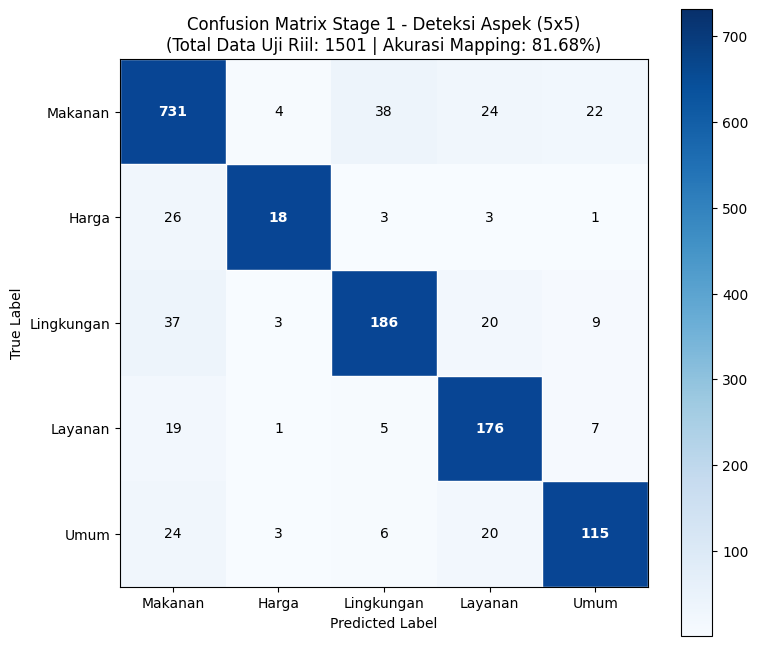


         CLASSIFICATION REPORT GLOBAL STAGE 1 (81.68%)
              precision    recall  f1-score   support

     Makanan     0.8734    0.8926    0.8829       819
       Harga     0.6207    0.3529    0.4500        51
  Lingkungan     0.7815    0.7294    0.7546       255
     Layanan     0.7243    0.8462    0.7805       208
        Umum     0.7468    0.6845    0.7143       168

    accuracy                         0.8168      1501
   macro avg     0.7493    0.7011    0.7164      1501
weighted avg     0.8143    0.8168    0.8133      1501



In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==================================================================
# 🔄 PROSES RE-MAPPING SINKRON 5x5 (MENGGUNAKAN INDEKS POSISIONAL ILOC)
# ==================================================================
all_true_stage1 = []
all_pred_stage1 = []

labels_stage1 = ["Makanan", "Harga", "Lingkungan", "Layanan", "Umum"]

prediksi_biner = {}
aktual_biner = {}

for asp in aspek_list:
    # 🛠️ PERBAIKAN UTAMA: Tambahkan .values agar bertipe numpy array murni (indeks otomatis reset dari 0)
    aktual_biner[asp] = y_test_dict[asp].values
    
    # Kupas pipeline SMOTE untuk mengambil classifier murninya
    if hasattr(model_aspek[asp], 'named_steps'):
        model_murni = model_aspek[asp].named_steps['classifier']
        prediksi_biner[asp] = model_murni.predict(X_test_dict[asp])
    else:
        prediksi_biner[asp] = model_aspek[asp].predict(X_test_dict[asp])

# Loop baris demi baris menggunakan panjang total data uji secara aman
num_rows = len(df_test)
for idx in range(num_rows):
    # Cari aspek apa saja yang aslinya bernilai 1 di baris ini (Aman dari KeyError karena menggunakan numpy murni)
    aspek_asli = [asp for asp in aspek_list if aktual_biner[asp][idx] == 1]
    # Cari aspek apa saja yang ditebak bernilai 1 oleh model di baris ini
    aspek_tebakan = [asp for asp in aspek_list if prediksi_biner[asp][idx] == 1]
    
    # 1. Tentukan True Label (Jika multi-label, ambil aspek pertama. Jika tidak ada, masuk Umum)
    if aspek_asli:
        true_label = aspek_asli[0].capitalize()
    else:
        true_label = "Umum"
        
    # 2. Tentukan Predicted Label (Jika multi-label, ambil tebakan aspek pertama. Jika tidak ada, masuk Umum)
    if aspek_tebakan:
        pred_label = aspek_tebakan[0].capitalize()
    else:
        pred_label = "Umum"
        
    all_true_stage1.append(true_label)
    all_pred_stage1.append(pred_label)


# ==================================================================
# 📊 GENERATE SINGLE CONFUSION MATRIX (5x5)
# ==================================================================
cm_stage1 = confusion_matrix(
    all_true_stage1,
    all_pred_stage1,
    labels=labels_stage1
)


# ==================================================================
# 🎨 VISUALISASI MATRIKS GABUNGAN (AUTOMATIC)
# ==================================================================
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stage1,
    display_labels=labels_stage1
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

# MENIMPA WARNA DIAGONAL (TRUE POSITIVE) SECARA MANUAL
warna_biru_tua = '#084594' 
n_labels = len(labels_stage1)

for i in range(n_labels):
    for j in range(n_labels):
        text_obj = disp.text_[i, j]
        
        # JIKA DIAGONAL (True Positive)
        if i == j:
            rect = patches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, 
                facecolor=warna_biru_tua, 
                edgecolor='white', 
                linewidth=1,
                zorder=1
            )
            ax.add_patch(rect)
            
            text_obj.set_zorder(2)
            text_obj.set_color("white")     # Angka diagonal jadi putih
            text_obj.set_weight("bold")     # Angka diagonal jadi tebal
            
        else:
            text_obj.set_color("black")     # Angka salah tebak tetap hitam

# Hitung nilai akurasi mapping 5x5
report_dict = classification_report(
    all_true_stage1, 
    all_pred_stage1, 
    labels=labels_stage1,
    output_dict=True,
    zero_division=0
)
acc_matriks = report_dict['accuracy']

plt.title(f"Confusion Matrix Stage 1 - Deteksi Aspek (5x5)\n(Total Data Uji Riil: {len(all_true_stage1)} | Akurasi Mapping: {acc_matriks*100:.2f}%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# ==================================================================
# 📝 PRINT CLASSIFICATION REPORT SINKRON
# ==================================================================
print("\n" + "="*60)
print(f"         CLASSIFICATION REPORT GLOBAL STAGE 1 ({acc_matriks*100:.2f}%)")
print("="*60)

report = classification_report(
    all_true_stage1, 
    all_pred_stage1, 
    labels=labels_stage1,
    digits=4,
    zero_division=0
)

print(report)
print("="*60)